# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/ANALYTICS/Colaboratory/data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [3]:
season_mapping = {
    12:1, 1:1, 2:1,
    3:2, 4:2, 5:2,
    6:3, 7:3, 8:3, 9:3,
    10:4, 11:4
}

df['weather_season_india'] = df['month'].map(season_mapping)

In [4]:
df['weather_season_india'].tail(10)

,weather_season_india
datetime,
2012-12-19 14:00:00,1
2012-12-19 15:00:00,1
2012-12-19 16:00:00,1
2012-12-19 17:00:00,1
2012-12-19 18:00:00,1
2012-12-19 19:00:00,1
2012-12-19 20:00:00,1
2012-12-19 21:00:00,1
2012-12-19 22:00:00,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [7]:
avg_rents_by_month = df['count'].resample('ME').mean()

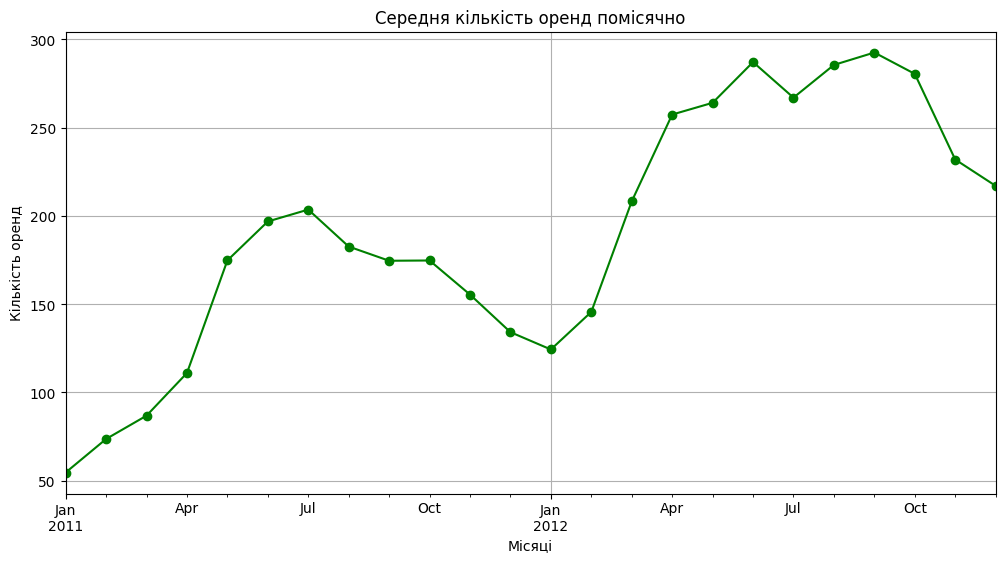

In [9]:
avg_rents_by_month.plot(
    figsize = (12,6),
    marker = 'o',
    color = 'green',
    title = 'Середня кількість оренд помісячно',
    xlabel = 'Місяці',
    ylabel = 'Кількість оренд',
    grid = True
);

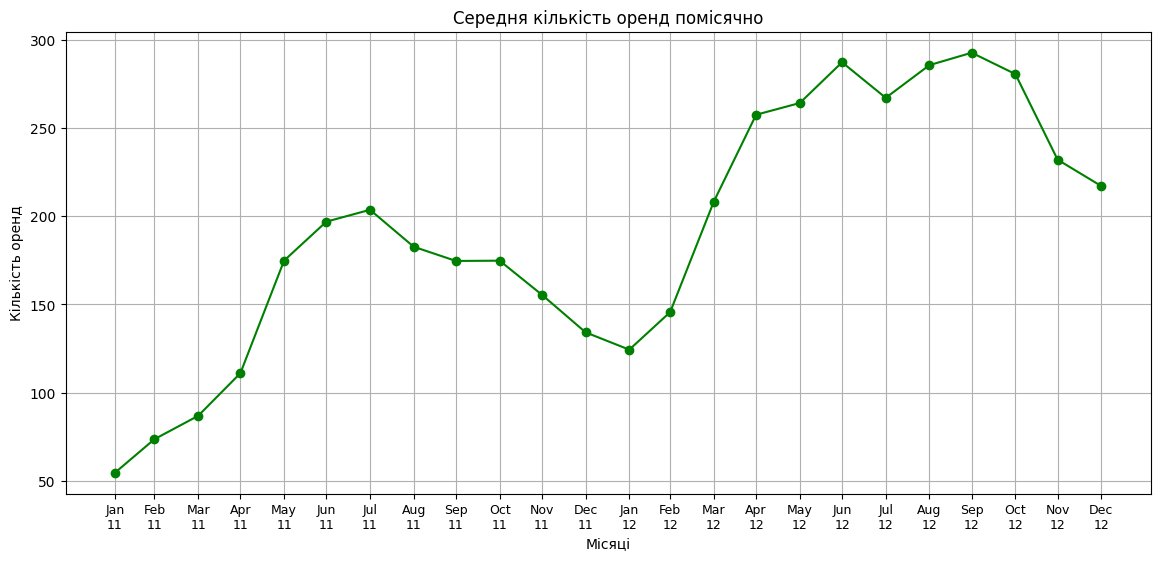

In [12]:
plt.figure(figsize = (14,6))

plt.plot(
    avg_rents_by_month.index,
    avg_rents_by_month.values,
    marker = 'o',
    color = 'green'
)

plt.title('Середня кількість оренд помісячно')
plt.xlabel('Місяці')
plt.ylabel('Кількість оренд')
plt.grid(True)

month_labels = avg_rents_by_month.index.strftime('%b\n%y')
plt.xticks(avg_rents_by_month.index, month_labels, fontsize = 9)   #з цією частиною коду допоміг АІ

plt.show()

Відмінності полягають перш за все в простоті написанні коду - через pandas все пишеться всередині однієї функції, а в matplotlib кожного разу виводиться новим рядком коду.

За простоту подобається pandas, але за функціонал matplotlib. Хоча другий поки дається тяжче.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [13]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

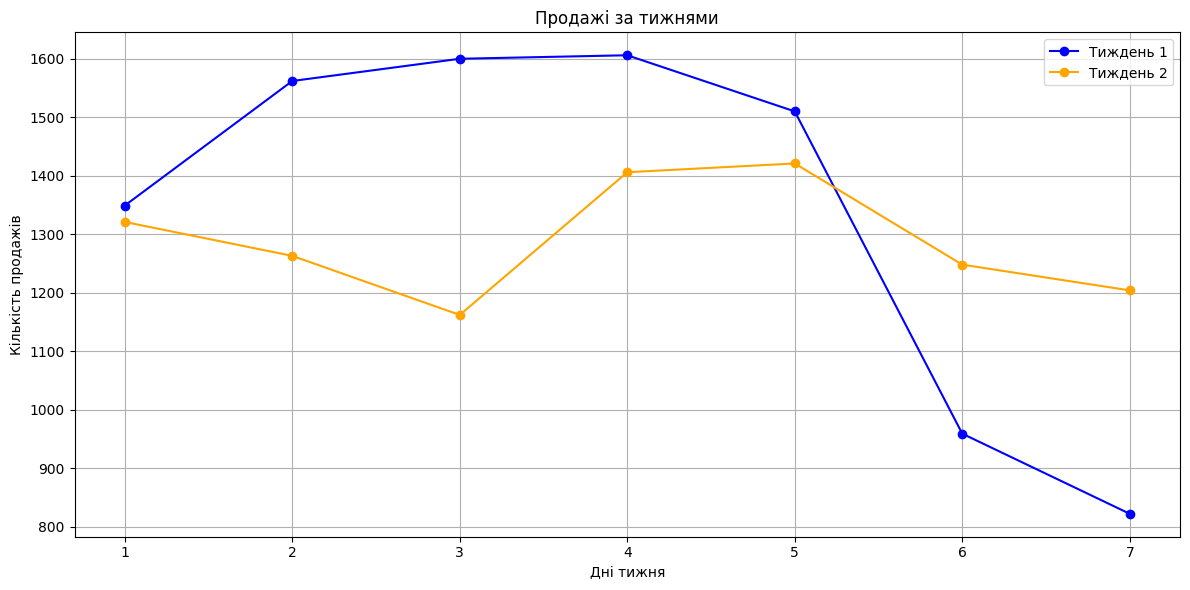

In [15]:
plt.figure(figsize = (12,6))

plt.plot(days, sales_week1, color = 'blue', label = 'Тиждень 1', marker = 'o')
plt.plot(days, sales_week2, color = 'orange', label = 'Тиждень 2', marker = 'o')

plt.title('Продажі за тижнями')
plt.xlabel('Дні тижня')
plt.ylabel('Кількість продажів')
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

In [18]:
week1 = np.array(sales_week1)
week2 = np.array(sales_week2)

std_week1 = np.std(week1)
std_week2 = np.std(week2)

print(f"Стандартнє відхилення першого тижня: {std_week1:.2f}")
print(f"Стандартнє відхилення другого тижня: {std_week2:.2f}")

#цю частину мені підказав та пояснив АІ, адже я думав йти через умовні середні, медіани і тд. АІ сказав, що відхилення точно покаже і власне показав, як це зробити

Стандартнє відхилення першого тижня: 300.00
Стандартнє відхилення другого тижня: 90.91


1) Візуально другий графік здається стабільнішим, адже не має таких сильних стрибків, як перший

2) Завдяки розрахуванню відхилення стає чітко видно різницю між цими двома графіками (для першого тижня воно становить 300.00, а для другого — лише 90.91, що підтверджує його вищу стабільність)

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [27]:
avg_temp_by_month = df['temp'].resample('ME').mean()

# quarter_rents = df['count'].resample('QE').mean() - було ось так, але АІ показав, як потрібно переробити

quarter_rents = df.groupby(df.index.quarter)['count'].mean()

#humidity_by_hours = df.groupby('humidity')['hour'].mean()  - AI сказав, що для гістограми не потрібно

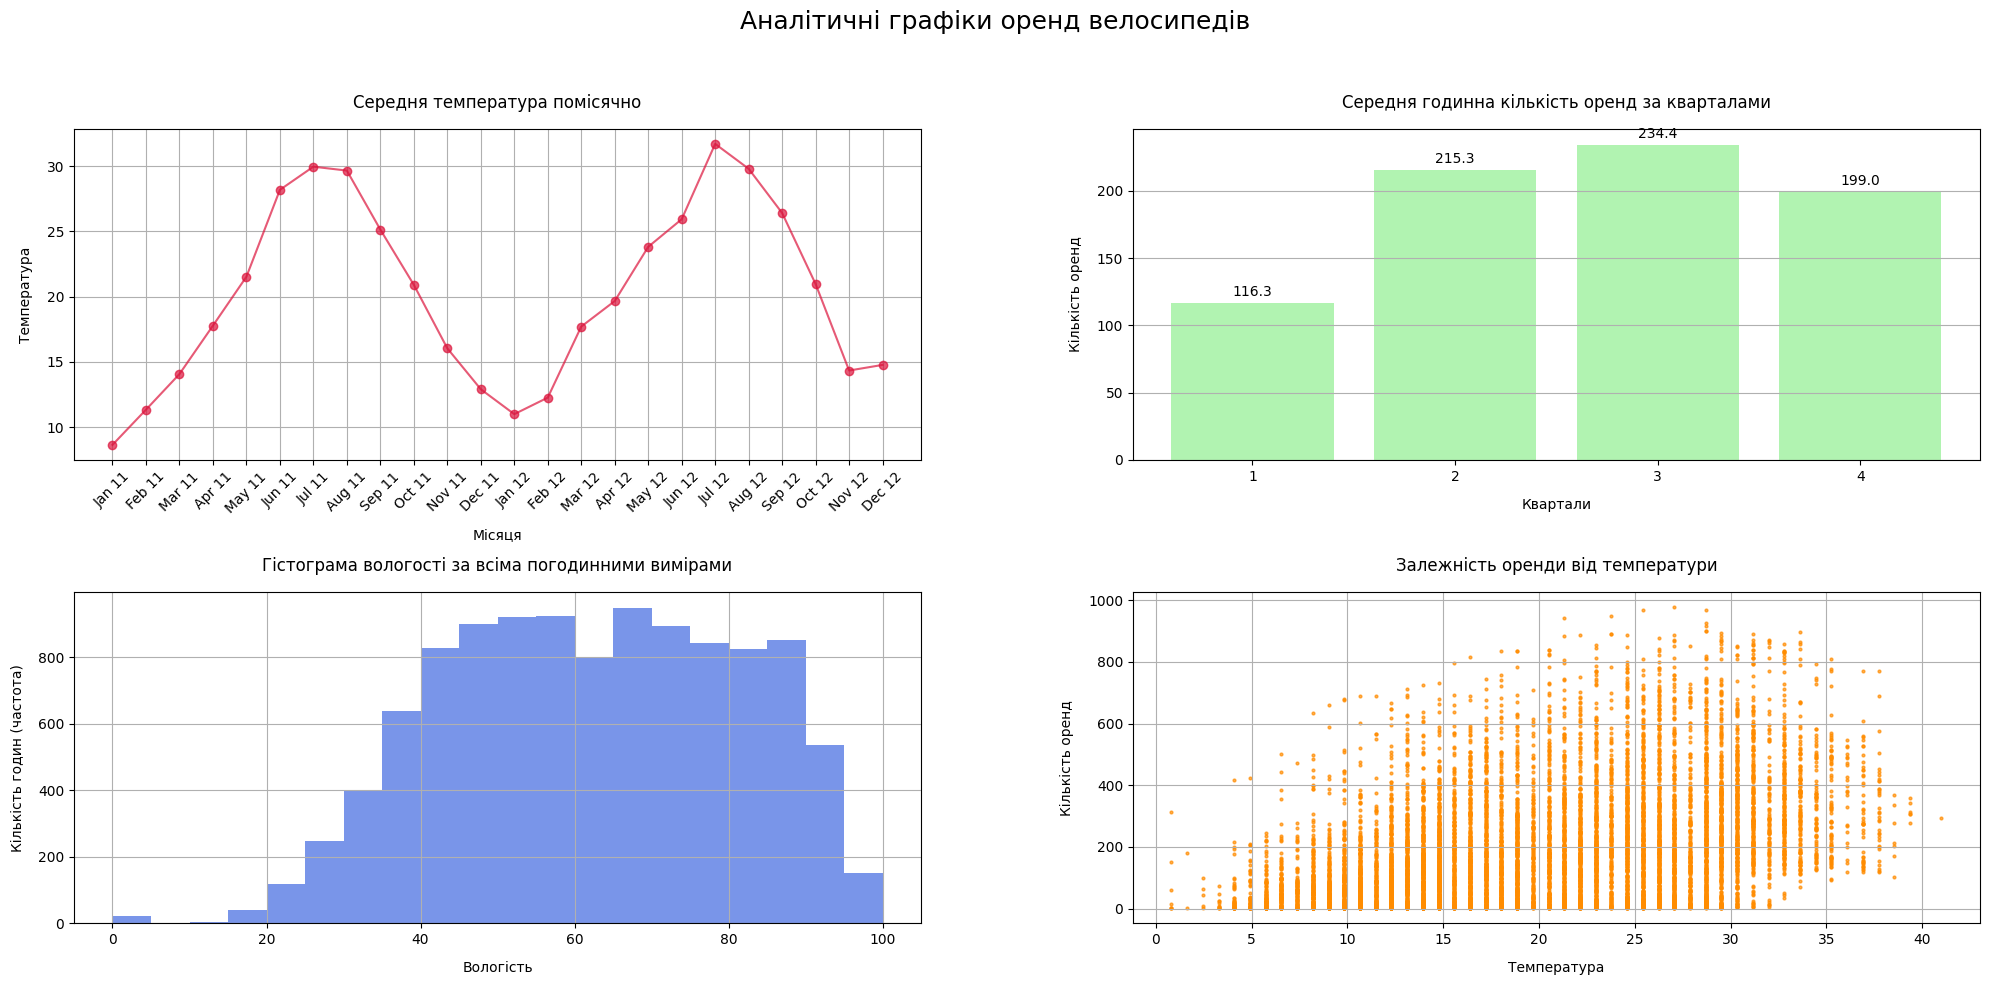

In [56]:
plt.figure(figsize = (20,10))

plt.subplot(2,2,1)
plt.plot(avg_temp_by_month.index.strftime('%b %y'), avg_temp_by_month.values, marker = 'o', color = 'crimson', alpha = 0.7)
plt.title('Середня температура помісячно', pad=15) # просив АІ за допомогу, щоб підписам зробити відступи, адже ніби злипаються
plt.xlabel('Місяця', labelpad=10) # аналогічно і тут просив
plt.ylabel('Температура', labelpad=10)
plt.xticks(rotation = 45)
plt.grid(True)

plt.subplot(2,2,2)
plt.bar(quarter_rents.index, quarter_rents.values, color = 'lightgreen', alpha = 0.7)
plt.title('Середня годинна кількість оренд за кварталами', pad=15)
plt.xlabel('Квартали', labelpad=10)
plt.ylabel('Кількість оренд', labelpad=10)
plt.xticks(quarter_rents.index)
plt.grid(axis = 'y') # AI підказав, як правильно написати по віссі У

for q, v in zip(quarter_rents.index, quarter_rents.values):
    plt.text(q, v + 3, f'{v:.1f}', ha='center', va='bottom', fontsize=10) # хотів самому зробити підписи, але довго мучався і не виходило навіть із АІ - дійшли до такого компромісу, спробувавши інший варіант

plt.subplot(2,2,3)
plt.hist(df['humidity'], bins = 20, color = 'royalblue', alpha = 0.7)
plt.title('Гістограма вологості за всіма погодинними вимірами', pad=15)
plt.xlabel('Вологість', labelpad=10)
plt.ylabel('Кількість годин (частота)', labelpad=10)
plt.grid(True)

plt.subplot(2,2,4)
plt.scatter(df['temp'], df['count'], color = 'darkorange', s = 4, alpha = 0.7 )
plt.title('Залежність оренди від температури', pad=15)
plt.xlabel('Температура', labelpad=10)
plt.ylabel('Кількість оренд', labelpad=10)
plt.grid(True)

plt.suptitle('Аналітичні графіки оренд велосипедів', fontsize = 18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(hspace=0.4, wspace=0.25) # AI сказав за це налаштування
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

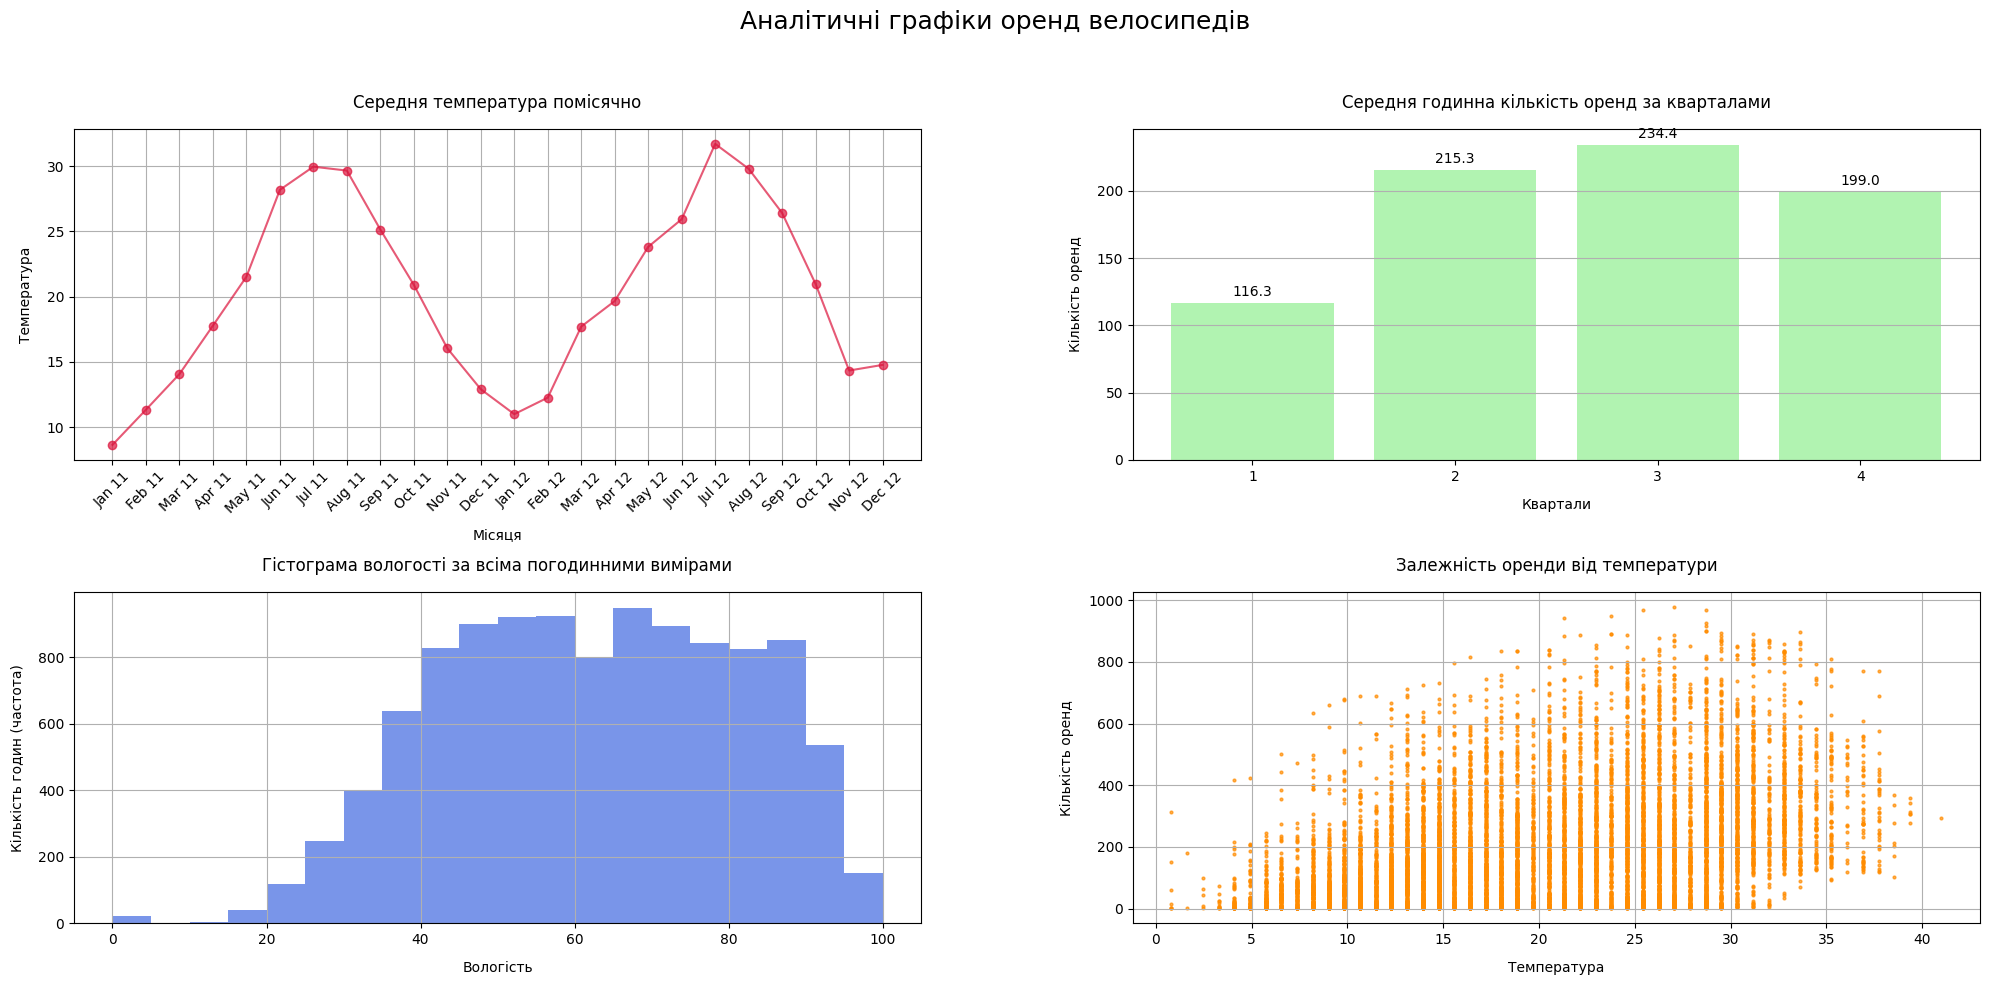

In [58]:
fig, ax = plt.subplots(2,2, figsize = (20,10))

ax[0, 0].plot(avg_temp_by_month.index.strftime('%b %y'), avg_temp_by_month.values, marker = 'o', color = 'crimson', alpha = 0.7)
ax[0, 0].set_title('Середня температура помісячно', pad=15)
ax[0, 0].set_xlabel('Місяця', labelpad=10)
ax[0, 0].set_ylabel('Температура', labelpad=10)
ax[0, 0].tick_params(axis = 'x', rotation = 45)
ax[0, 0].grid(True)

ax[0, 1].bar(quarter_rents.index, quarter_rents.values, color = 'lightgreen', alpha = 0.7)
ax[0, 1].set_title('Середня годинна кількість оренд за кварталами', pad=15)
ax[0, 1].set_xlabel('Квартали', labelpad=10)
ax[0, 1].set_ylabel('Кількість оренд', labelpad=10)
ax[0, 1].set_xticks(quarter_rents.index)
ax[0, 1].grid(axis = 'y')

for q, v in zip(quarter_rents.index, quarter_rents.values):
    ax[0, 1].text(q, v + 3, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

ax[1, 0].hist(df['humidity'], bins = 20, color = 'royalblue', alpha = 0.7)
ax[1, 0].set_title('Гістограма вологості за всіма погодинними вимірами', pad=15)
ax[1, 0].set_xlabel('Вологість', labelpad=10)
ax[1, 0].set_ylabel('Кількість годин (частота)', labelpad=10)
ax[1, 0].grid(True)

ax[1, 1].scatter(df['temp'], df['count'], color = 'darkorange', s = 4, alpha = 0.7 )
ax[1, 1].set_title('Залежність оренди від температури', pad=15)
ax[1, 1].set_xlabel('Температура', labelpad=10)
ax[1, 1].set_ylabel('Кількість оренд', labelpad=10)
ax[1, 1].grid(True)

fig.suptitle('Аналітичні графіки оренд велосипедів', fontsize = 18)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(hspace=0.4, wspace=0.25)

plt.show()

Із supblotS зручніше звернутись до конкретного підграфіка - навіть не обов'язково писати все по порядку, як в методі subplot. Просто ставиться індекс і дописується необхідний параметр. Та і загалом сам метод є сучаснішим і дає більше контролю, попри свою певну складність в написанні від попереднього методу.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

Буду відвертий, зважаючи на велику кількість налаштувань про які я не знаю - практично всю роботу із цим графіком за мене зробив АІ - я лише намагався зрозуміти, як воно і що воно до чого застосовується.

In [61]:
monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min'])

avg_by_month = monthly_stats['mean']
max_by_month = monthly_stats['max']
min_by_month = monthly_stats['min']

In [64]:
import matplotlib.ticker as ticker   #AI радив для одного із налаштувань

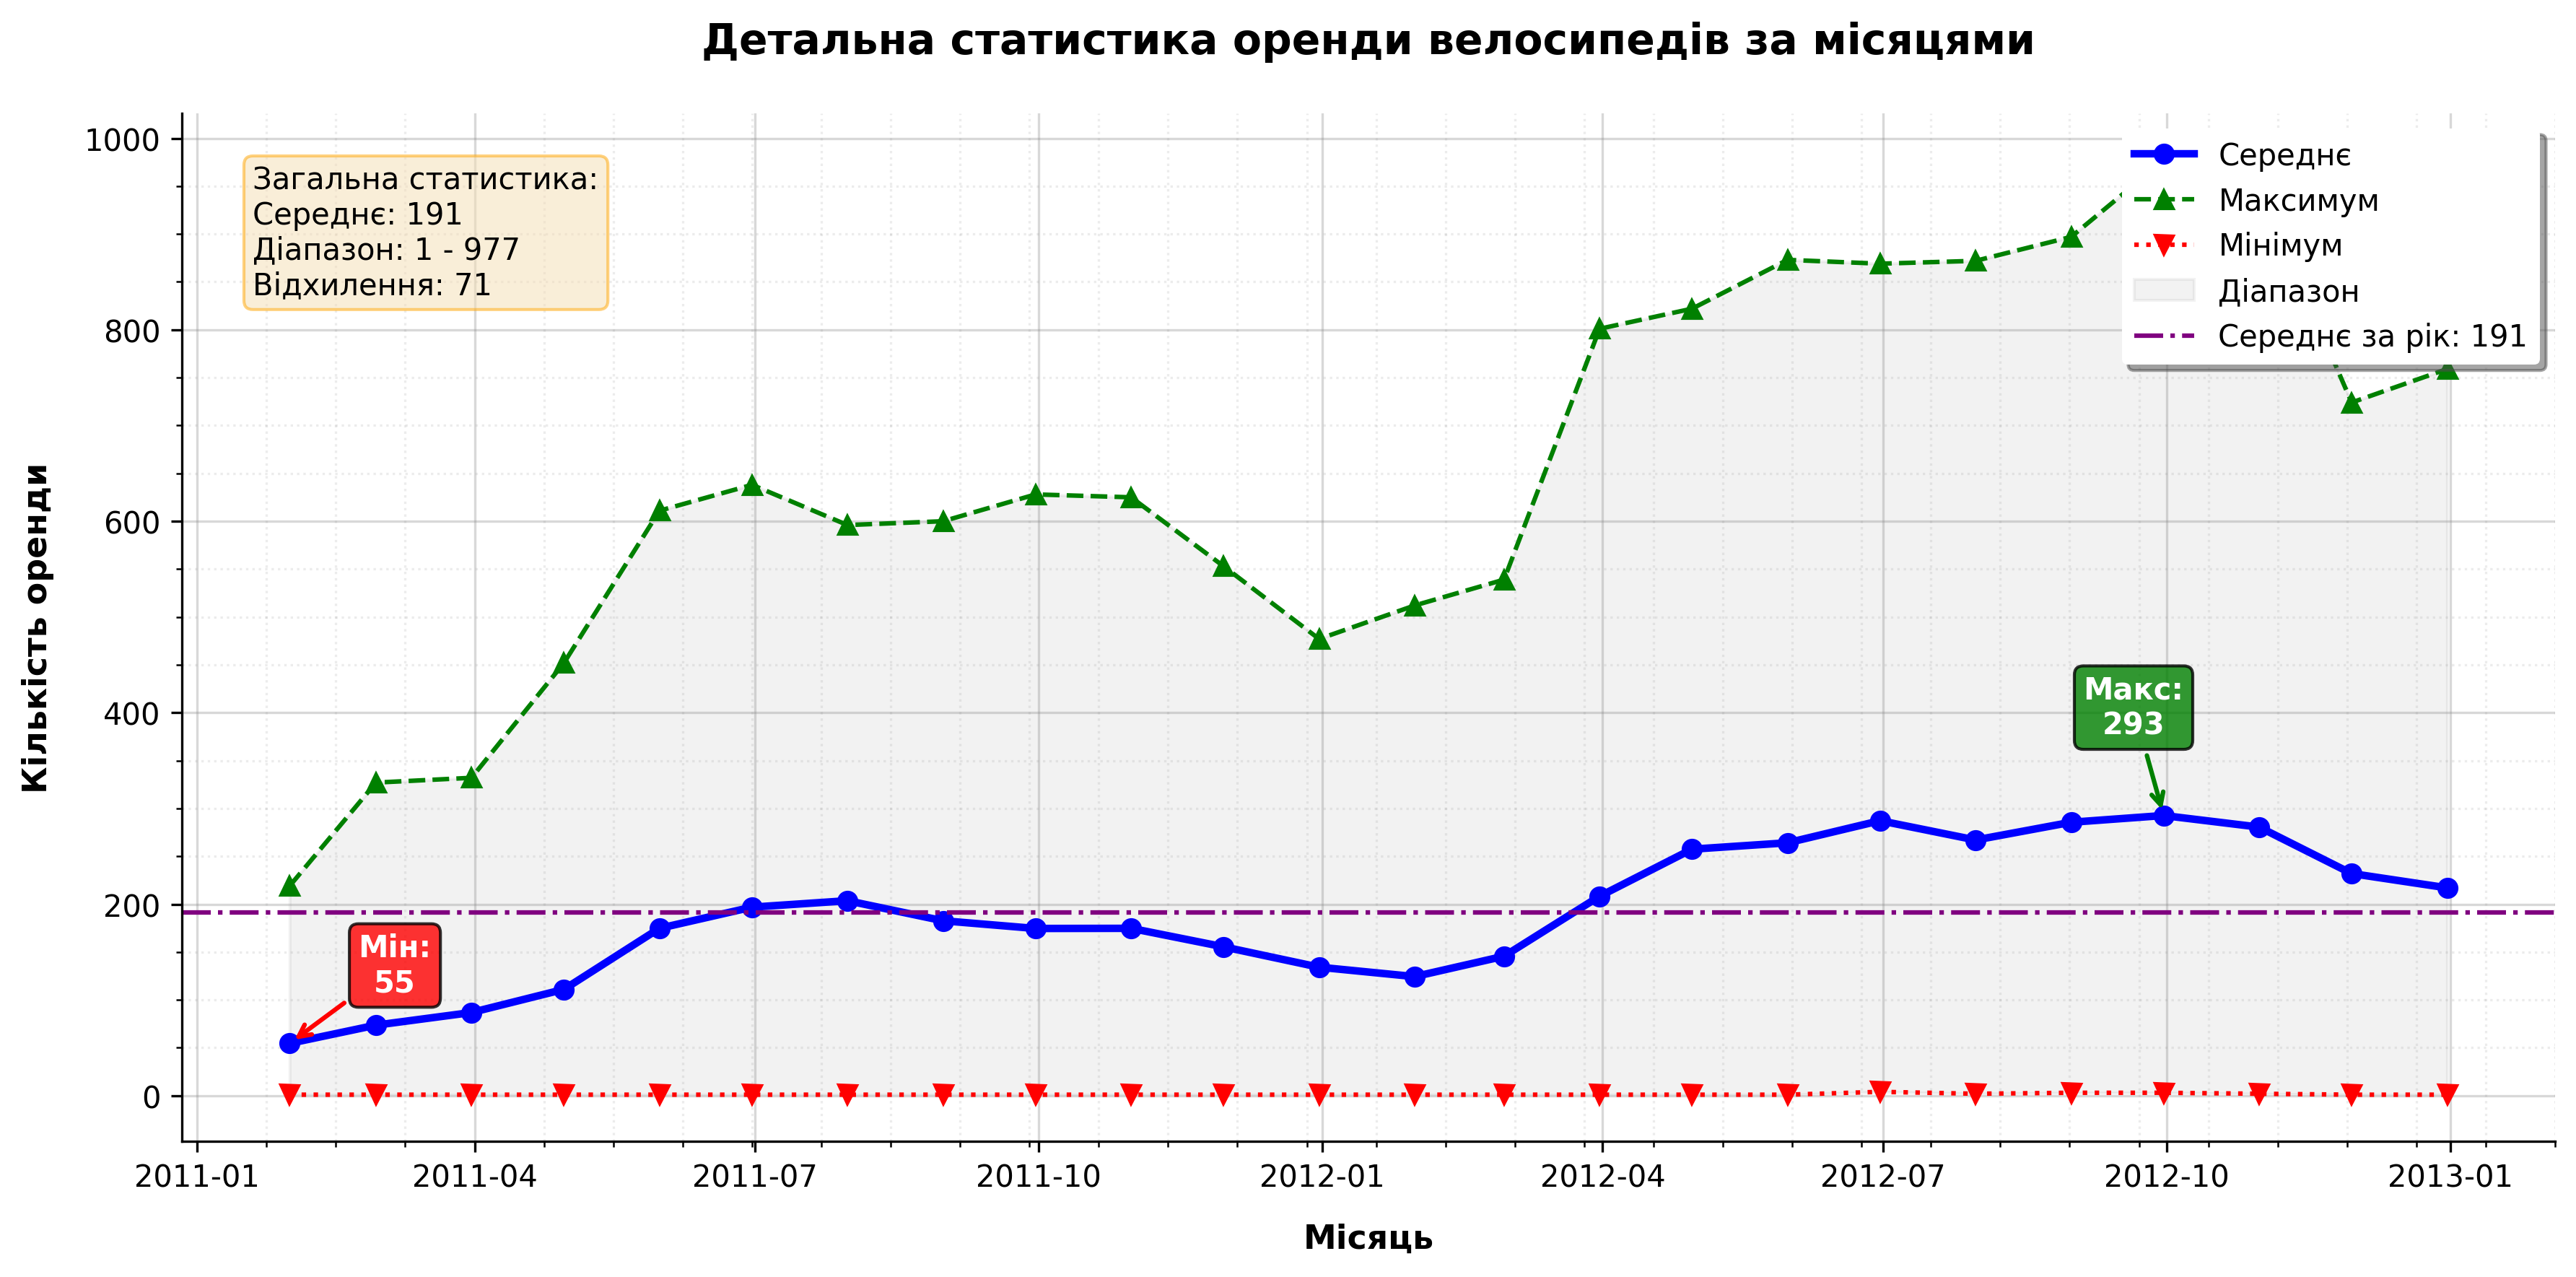

In [69]:
fig, ax = plt.subplots(figsize = (12, 6), dpi=300)

ax.plot(avg_by_month.index, avg_by_month.values, linestyle='-', marker='o', color='blue', linewidth=2.5, label='Середнє')
ax.plot(max_by_month.index, max_by_month.values, linestyle='--', marker='^', color='green', linewidth=1.5, label='Максимум')
ax.plot(min_by_month.index, min_by_month.values, linestyle=':', marker='v', color='red', linewidth=1.5, label='Мінімум')

ax.fill_between(avg_by_month.index, max_by_month.values, min_by_month.values, color='gray', alpha=0.1, label='Діапазон')

highest_idx = avg_by_month.idxmax()
highest_val = avg_by_month.max()
lowest_idx = avg_by_month.idxmin()
lowest_val = avg_by_month.min()

ax.annotate(f'Макс:\n{highest_val:.0f}',
            xy=(highest_idx, highest_val), xytext=(-10, 25), textcoords='offset points',
            ha='center', va='bottom', color='white', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='green', alpha=0.8),
            arrowprops=dict(arrowstyle="->", color='green', linewidth=1.5))

ax.annotate(f'Мін:\n{lowest_val:.0f}',
            xy=(lowest_idx, lowest_val), xytext=(35, 15), textcoords='offset points',
            ha='center', va='bottom', color='white', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='red', alpha=0.8),
            arrowprops=dict(arrowstyle="->", color='red', linewidth=1.5))

year_avg = avg_by_month.mean()
ax.axhline(y=year_avg, color='purple', linestyle='-.', linewidth=1.5, label=f'Середнє за рік: {year_avg:.0f}')

ax.grid(visible=True, which='major', color='gray', linestyle='-', alpha=0.3)
ax.grid(visible=True, which='minor', color='gray', linestyle=':', alpha=0.15)
ax.minorticks_on()

ax.legend(loc='upper right', shadow=True, facecolor='white', edgecolor='none')

stats_text = (
    "Загальна статистика:\n"
    f"Середнє: {year_avg:.0f}\n"
    f"Діапазон: {min_by_month.min():.0f} - {max_by_month.max():.0f}\n"
    f"Відхилення: {avg_by_month.std():.0f}"
)

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5, edgecolor='orange')
ax.text(0.03, 0.95, stats_text, transform=ax.transAxes, fontsize=10, va='top', bbox=props)

ax.set_title('Детальна статистика оренди велосипедів за місяцями', fontsize=14, weight='bold', pad=20)
ax.set_xlabel('Місяць', fontsize=11, weight='bold', labelpad=10)
ax.set_ylabel('Кількість оренди', fontsize=11, weight='bold', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

1) Анотації привертають свою увагу і відразу ще до аналізу графіку дають зрозуміти його тенденцію.

2) Для того, щоб візуально показати рокзид наших даних між двома графіками та зрозуміти, наскільки стабільними є дані.

3) Дає змогу зібрати основні показники в одному місці та економить цим час, ніж аналізувати по кожному графіку окремо.